**Problem 1**

Часть (a): Метод обратного преобразования


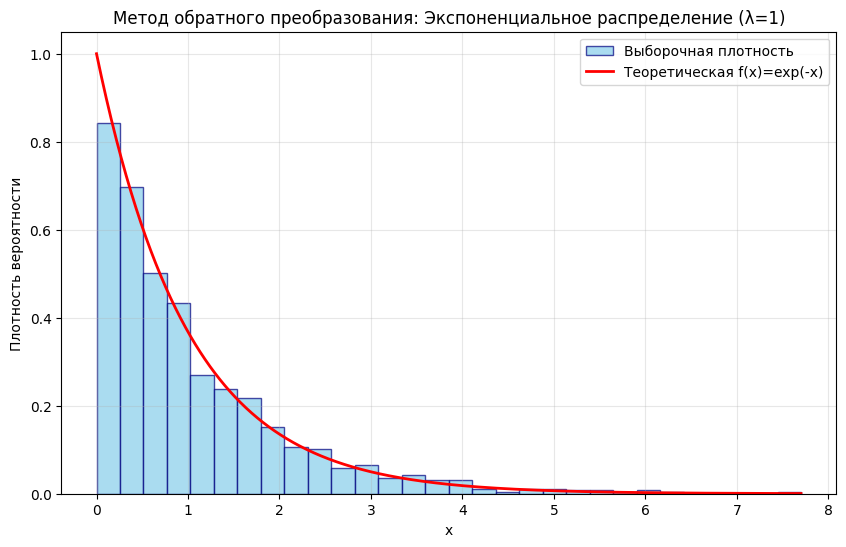

Размер выборки: 1000
Выборочное среднее: 1.0493 (теоретическое: 1.0000)
Выборочная дисперсия: 1.1169 (теоретическая: 1.0000)

Часть (b): Метод принятия-отклонения

(b.i) Нахождение минимальной константы c:
f(x) = (3/2)*(1 - x^2)
g(x) = 1 для x ∈ [0,1]
Находим максимум f(x):
f'(x) = -3x = 0 => x = 0
f(0) = 1.5, f(1) = 0
Максимум f(x) = 1.5 при x = 0
Минимальная константа c = 1.5

(b.ii)-(b.iii) Генерация выборки размером n=1000...


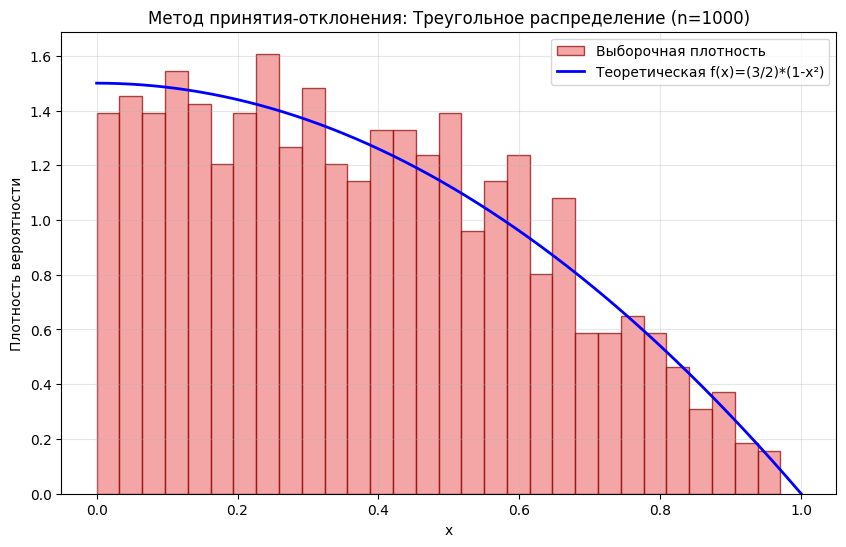

Эффективность метода: 64.89%
Теоретическая эффективность (1/c): 66.67%

Статистические характеристики:
Выборочное среднее: 0.3797 (теоретическое: 0.3750)
Выборочная дисперсия: 0.0575 (теоретическая: 0.0594)

Проверка неравенства f(x) ≤ c·g(x) для x ∈ [0,1]:
  x=0.00: f(x)=1.500, c·g(x)=1.500, f(x) ≤ c·g(x)? True
  x=0.25: f(x)=1.406, c·g(x)=1.500, f(x) ≤ c·g(x)? True
  x=0.50: f(x)=1.125, c·g(x)=1.500, f(x) ≤ c·g(x)? True
  x=0.75: f(x)=0.656, c·g(x)=1.500, f(x) ≤ c·g(x)? True
  x=1.00: f(x)=0.000, c·g(x)=1.500, f(x) ≤ c·g(x)? True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================================
# Часть (a): Метод обратного преобразования
# ===========================================
print("="*60)
print("Часть (a): Метод обратного преобразования")
print("="*60)

# Параметры согласно заданию
n = 1000
lambd = 1

# Генерация выборки методом обратного преобразования
U = np.random.uniform(0, 1, n)
X = -np.log(U) / lambd  # Экспоненциальное распределение

# Теоретическая плотность
x_range_a = np.linspace(0, np.max(X), 1000)
pdf_theoretical = lambd * np.exp(-lambd * x_range_a)

# Построение графика
plt.figure(figsize=(10, 6))
plt.hist(X, bins=30, density=True, alpha=0.7, color='skyblue',
         edgecolor='navy', label='Выборочная плотность')
plt.plot(x_range_a, pdf_theoretical, 'r-', linewidth=2,
         label='Теоретическая f(x)=exp(-x)')
plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.title('Метод обратного преобразования: Экспоненциальное распределение (λ=1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод статистик
print(f"Размер выборки: {n}")
print(f"Выборочное среднее: {np.mean(X):.4f} (теоретическое: {1/lambd:.4f})")
print(f"Выборочная дисперсия: {np.var(X):.4f} (теоретическая: {1/lambd**2:.4f})")
print()

# ===========================================
# Часть (b): Метод принятия-отклонения
# ===========================================
print("="*60)
print("Часть (b): Метод принятия-отклонения")
print("="*60)

# Определение функций плотности
def f(x):
    """Целевая плотность: f(x) = (3/2)*(1 - x^2), 0 ≤ x ≤ 1"""
    return 1.5 * (1 - x**2)

def g(x):
    """Предложенная плотность: равномерная на [0,1]"""
    return 1.0  # g(x) = 1 для 0 ≤ x ≤ 1

# (b.i) Нахождение минимальной константы c
print("\n(b.i) Нахождение минимальной константы c:")
print("f(x) = (3/2)*(1 - x^2)")
print("g(x) = 1 для x ∈ [0,1]")
print("Находим максимум f(x):")
print("f'(x) = -3x = 0 => x = 0")
print("f(0) = 1.5, f(1) = 0")
print("Максимум f(x) = 1.5 при x = 0")
print("Минимальная константа c = 1.5")
c = 1.5

# (b.ii) Реализация алгоритма принятия-отклонения
def acceptance_rejection(n):
    """Генерация выборки размером n методом принятия-отклонения"""
    accepted = []
    attempts = 0

    while len(accepted) < n:
        attempts += 1
        Y = np.random.uniform(0, 1)  # Генерация из g(x)
        U = np.random.uniform(0, 1)

        # Проверка условия принятия
        if U <= f(Y) / (c * g(Y)):  # g(Y) = 1
            accepted.append(Y)

    acceptance_rate = n / attempts
    return np.array(accepted), acceptance_rate

# (b.iii) Генерация выборки и построение графика
print(f"\n(b.ii)-(b.iii) Генерация выборки размером n={n}...")
Y, acceptance_rate = acceptance_rejection(n)

# Теоретическая плотность для графика
x_range_b = np.linspace(0, 1, 1000)
pdf_target = f(x_range_b)

# Построение графика
plt.figure(figsize=(10, 6))
plt.hist(Y, bins=30, density=True, alpha=0.7, color='lightcoral',
         edgecolor='darkred', label='Выборочная плотность')
plt.plot(x_range_b, pdf_target, 'b-', linewidth=2,
         label='Теоретическая f(x)=(3/2)*(1-x²)')
plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.title(f'Метод принятия-отклонения: Треугольное распределение (n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод статистик
print(f"Эффективность метода: {acceptance_rate*100:.2f}%")
print(f"Теоретическая эффективность (1/c): {(1/c)*100:.2f}%")

# Теоретические моменты
mu_theoretical = 0.375  # 3/8
var_theoretical = 19/320  # ≈ 0.059375

print(f"\nСтатистические характеристики:")
print(f"Выборочное среднее: {np.mean(Y):.4f} (теоретическое: {mu_theoretical:.4f})")
print(f"Выборочная дисперсия: {np.var(Y):.4f} (теоретическая: {var_theoretical:.4f})")

# Проверка неравенства f(x) ≤ c·g(x)
print(f"\nПроверка неравенства f(x) ≤ c·g(x) для x ∈ [0,1]:")
test_points = np.linspace(0, 1, 5)
for x in test_points:
    print(f"  x={x:.2f}: f(x)={f(x):.3f}, c·g(x)={c*g(x):.3f}, f(x) ≤ c·g(x)? {f(x) <= c*g(x)}")

**Problem 2**

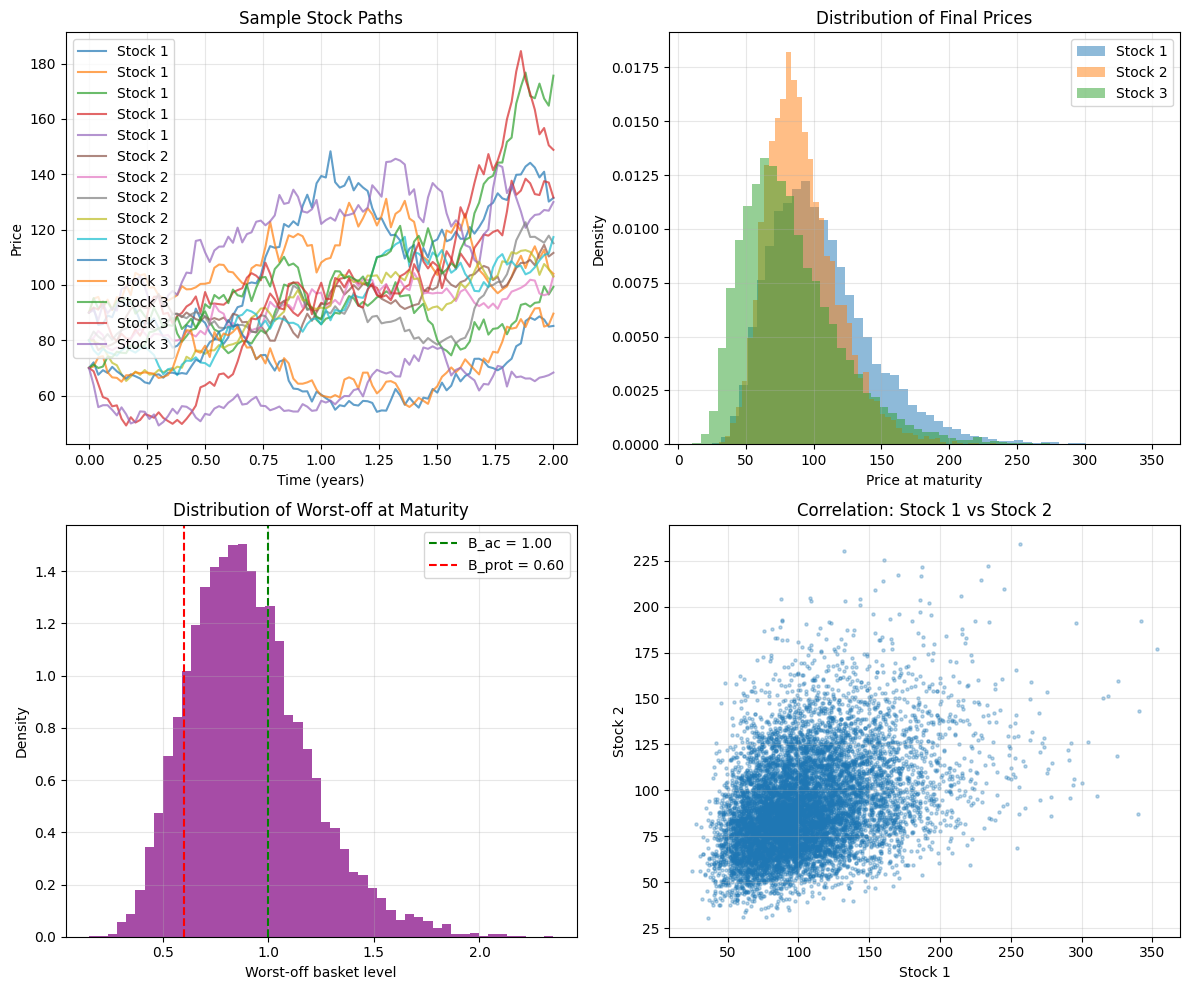

Часть (b): Цена продукта
Цена: 95.2131
Стандартная ошибка: 0.203985

Часть (c): Греки продукта

Дельта (Δ):
  Акция 1: 0.000000
  Акция 2: 0.000000
  Акция 3: 0.000000

Гамма (Γ):
  Акция 1: 0.000000
  Акция 2: 0.000000
  Акция 3: 0.000000

Вега (ν):
  Акция 1: -42.152667
  Акция 2: -12.196744
  Акция 3: -49.142851

Часть (d): Статическое дельта-гамма хеджирование

1. ДЕЛЬТА-ХЕДЖ:
Количество акций для хеджирования 100 продуктов:
  Акция 1: -0.00 акций (long)
  Акция 2: -0.00 акций (long)
  Акция 3: -0.00 акций (long)

2. ГАММА-ХЕДЖ ЧЕРЕЗ ATM STRADDLES:
Количество ATM straddles для гамма-хеджирования 100 продуктов:
  Акция 1: -0.00 straddles (buy)
    Стоимость одного straddle: 25.41
    Стоимость позиции: 0.00
  Акция 2: -0.00 straddles (buy)
    Стоимость одного straddle: 18.82
    Стоимость позиции: 0.00
  Акция 3: -0.00 straddles (buy)
    Стоимость одного straddle: 23.15
    Стоимость позиции: 0.00

Общая стоимость гамма-хеджа: 0.00

3. ОБЩАЯ СТРАТЕГИЯ:

Комбинированная стратегия:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===========================================
# Часть (a): Генерация путей
# ===========================================
np.random.seed(42)
n_paths = 10000
n_steps = 100

# Параметры из задания
mu = np.array([0.08, 0.07, 0.09])
sigma = np.array([0.25, 0.20, 0.30])
R = np.array([[1.0, 0.40, 0.30],
              [0.40, 1.0, 0.50],
              [0.30, 0.50, 1.0]])
S0 = np.array([90.0, 80.0, 70.0])
T = 2.0

# Генерация коррелированных путей
dt = T / n_steps
L = np.linalg.cholesky(R)

# Инициализация
S = np.zeros((n_paths, n_steps + 1, 3))
S[:, 0, :] = S0

for t in range(1, n_steps + 1):
    Z = np.random.normal(0, 1, (n_paths, 3))
    Z_corr = Z @ L.T

    for i in range(3):
        S[:, t, i] = S[:, t-1, i] * np.exp(
            (mu[i] - 0.5*sigma[i]**2)*dt +
            sigma[i]*np.sqrt(dt)*Z_corr[:, i]
        )

# Графики для части (a)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Примеры путей
for i in range(3):
    axes[0, 0].plot(np.linspace(0, T, n_steps+1),
                   S[:5, :, i].T, alpha=0.7, label=f'Stock {i+1}')
axes[0, 0].set_xlabel('Time (years)')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Sample Stock Paths')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение конечных цен
for i in range(3):
    axes[0, 1].hist(S[:, -1, i], bins=50, alpha=0.5,
                   label=f'Stock {i+1}', density=True)
axes[0, 1].set_xlabel('Price at maturity')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Distribution of Final Prices')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Worst-off basket level
X = S / S0.reshape(1, 1, 3)  # Normalized prices
W = np.min(X, axis=2)  # Worst-off basket

axes[1, 0].hist(W[:, -1], bins=50, alpha=0.7, color='purple', density=True)
axes[1, 0].axvline(x=1.00, color='green', linestyle='--', label='B_ac = 1.00')
axes[1, 0].axvline(x=0.60, color='red', linestyle='--', label='B_prot = 0.60')
axes[1, 0].set_xlabel('Worst-off basket level')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Worst-off at Maturity')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Корреляция
axes[1, 1].scatter(S[:, -1, 0], S[:, -1, 1], alpha=0.3, s=5)
axes[1, 1].set_xlabel('Stock 1')
axes[1, 1].set_ylabel('Stock 2')
axes[1, 1].set_title('Correlation: Stock 1 vs Stock 2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===========================================
# Часть (b): Ценообразование с фиксированными случайными числами
# ===========================================
np.random.seed(42)
n_paths = 10000
n_steps = 100

# Параметры
r = 0.07  # Безрисковая ставка (для риск-нейтральной меры)
sigma = np.array([0.25, 0.20, 0.30])
R = np.array([[1.0, 0.40, 0.30],
              [0.40, 1.0, 0.50],
              [0.30, 0.50, 1.0]])
S0 = np.array([90.0, 80.0, 70.0])
T = 2.0
M = 4
N = 100
c = 0.05
B_ac = 1.00
B_prot = 0.60

# Функция генерации путей с фиксированными случайными числами
def generate_paths(S0_vec, sigma_vec, seed=42):
    np.random.seed(seed)
    dt = T / n_steps
    L = np.linalg.cholesky(R)

    S = np.zeros((n_paths, n_steps + 1, 3))
    S[:, 0, :] = S0_vec

    for t in range(1, n_steps + 1):
        Z = np.random.normal(0, 1, (n_paths, 3))
        Z_corr = Z @ L.T

        for i in range(3):
            S[:, t, i] = S[:, t-1, i] * np.exp(
                (r - 0.5*sigma_vec[i]**2)*dt +  # Используем риск-нейтральную меру
                sigma_vec[i]*np.sqrt(dt)*Z_corr[:, i]
            )
    return S

# Генерация базовых путей
S = generate_paths(S0, sigma)

# Функция ценообразования
def price_autocall(S_paths, S0_vec):
    n_paths = S_paths.shape[0]
    n_steps = S_paths.shape[1] - 1

    # Даты наблюдения
    obs_indices = np.linspace(0, n_steps, M+1, dtype=int)[1:]
    obs_times = np.linspace(0, T, M+1)[1:]

    # Нормализованные цены
    X_obs = S_paths[:, obs_indices, :] / S0_vec.reshape(1, 1, 3)
    W_obs = np.min(X_obs, axis=2)

    # Расчет выплат
    payoffs = np.zeros(n_paths)
    discount_factors = np.ones(n_paths) * np.exp(-r * T)

    for k in range(M):
        mask = payoffs == 0
        if np.any(mask):
            autocall_condition = W_obs[mask, k] >= B_ac
            if np.any(autocall_condition):
                idx = np.where(mask)[0][autocall_condition]
                payoffs[idx] = N * (1 + (k+1) * c)
                discount_factors[idx] = np.exp(-r * obs_times[k])

    # Пути без автоколла
    mask_no_autocall = payoffs == 0
    if np.any(mask_no_autocall):
        W_T = W_obs[mask_no_autocall, -1]
        protection_condition = W_T >= B_prot

        payoffs_protection = N * (1 + M * c)
        payoffs_participation = N * W_T

        payoffs[mask_no_autocall] = np.where(
            protection_condition,
            payoffs_protection,
            payoffs_participation
        )

    discounted_payoffs = payoffs * discount_factors
    return np.mean(discounted_payoffs), discounted_payoffs

# Расчет цены
price, discounted_payoffs = price_autocall(S, S0)
print("="*60)
print("Часть (b): Цена продукта")
print("="*60)
print(f"Цена: {price:.4f}")
print(f"Стандартная ошибка: {np.std(discounted_payoffs)/np.sqrt(n_paths):.6f}")

# ===========================================
# Часть (c): Корректный расчет греков
# ===========================================
def compute_greeks():
    # Сохраняем оригинальные случайные числа для последовательности
    base_seed = 42

    # Базовый расчет
    S_base = generate_paths(S0, sigma, seed=base_seed)
    base_price, _ = price_autocall(S_base, S0)

    # Дельта
    delta = np.zeros(3)
    bump_delta = 0.01

    for i in range(3):
        # Генерация с измененным S0 (но с тем же seed!)
        S0_up = S0.copy()
        S0_up[i] = S0[i] * (1 + bump_delta)

        S_up = generate_paths(S0_up, sigma, seed=base_seed)
        price_up, _ = price_autocall(S_up, S0_up)

        S0_down = S0.copy()
        S0_down[i] = S0[i] * (1 - bump_delta)

        S_down = generate_paths(S0_down, sigma, seed=base_seed)
        price_down, _ = price_autocall(S_down, S0_down)

        delta[i] = (price_up - price_down) / (2 * bump_delta * S0[i])

    # Гамма
    gamma = np.zeros(3)

    for i in range(3):
        # Используем те же price_up, price_down
        gamma[i] = (price_up - 2*base_price + price_down) / (bump_delta * S0[i])**2

    # Вега
    vega = np.zeros(3)
    bump_vega = 0.01

    for i in range(3):
        sigma_up = sigma.copy()
        sigma_up[i] += bump_vega

        S_up = generate_paths(S0, sigma_up, seed=base_seed)
        price_up, _ = price_autocall(S_up, S0)

        sigma_down = sigma.copy()
        sigma_down[i] = max(0.01, sigma[i] - bump_vega)

        S_down = generate_paths(S0, sigma_down, seed=base_seed)
        price_down, _ = price_autocall(S_down, S0)

        vega[i] = (price_up - price_down) / (2 * bump_vega)

    return delta, gamma, vega, base_price

# Расчет греков
delta, gamma, vega, base_price = compute_greeks()

print("\n" + "="*60)
print("Часть (c): Греки продукта")
print("="*60)
print("\nДельта (Δ):")
for i in range(3):
    print(f"  Акция {i+1}: {delta[i]:.6f}")

print("\nГамма (Γ):")
for i in range(3):
    print(f"  Акция {i+1}: {gamma[i]:.6f}")

print("\nВега (ν):")
for i in range(3):
    print(f"  Акция {i+1}: {vega[i]:.6f}")

# ===========================================
# Часть (d): Корректное хеджирование
# ===========================================
print("\n" + "="*60)
print("Часть (d): Статическое дельта-гамма хеджирование")
print("="*60)

# Рассчитываем необходимые позиции
N_products = 100  # Количество продуктов

print("\n1. ДЕЛЬТА-ХЕДЖ:")
print("Количество акций для хеджирования 100 продуктов:")
for i in range(3):
    n_shares = -delta[i] * N_products
    direction = "short" if n_shares < 0 else "long"
    print(f"  Акция {i+1}: {n_shares:.2f} акций ({direction})")

print("\n2. ГАММА-ХЕДЖ ЧЕРЕЗ ATM STRADDLES:")

# Гамма опциона в модели Блэка-Шоулза
def bs_gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

# Цена опциона
def bs_price(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

# Рассчитываем необходимое количество straddles для гамма-хеджирования
total_gamma_cost = 0
print("Количество ATM straddles для гамма-хеджирования 100 продуктов:")
for i in range(3):
    # Гамма одного ATM straddle (колл + пут)
    gamma_call = bs_gamma(S0[i], S0[i], T, r, sigma[i])
    gamma_put = gamma_call  # Для ATM опционов гамма одинакова
    gamma_straddle = gamma_call + gamma_put

    # Необходимое количество straddles
    n_straddles = -gamma[i] * N_products / gamma_straddle

    # Стоимость одного straddle
    call_price = bs_price(S0[i], S0[i], T, r, sigma[i], 'call')
    put_price = bs_price(S0[i], S0[i], T, r, sigma[i], 'put')
    straddle_price = call_price + put_price

    total_cost = abs(n_straddles) * straddle_price
    total_gamma_cost += total_cost

    direction = "sell" if n_straddles < 0 else "buy"
    print(f"  Акция {i+1}: {n_straddles:.2f} straddles ({direction})")
    print(f"    Стоимость одного straddle: {straddle_price:.2f}")
    print(f"    Стоимость позиции: {total_cost:.2f}")

print(f"\nОбщая стоимость гамма-хеджа: {total_gamma_cost:.2f}")

print("\n3. ОБЩАЯ СТРАТЕГИЯ:")
print("""
Комбинированная стратегия:
1. Дельта-хедж: занять позиции в базовых акциях согласно расчету дельты
2. Гамма-хедж: использовать ATM straddles для обнуления гаммы
3. Вега-риск остается нехеджированным в статической стратегии

Примечания:
- Вега продукта отрицательна, что означает риск при росте волатильности
- Для полного хеджирования потребовались бы динамические стратегии
- Корреляционный риск сложно хеджировать стандартными инструментами
""")